# Práctica 2 – Aprendizaje Automático II
## DQN para el entorno LunarLander-v3

### Autores

| Nombre | Correo |
|--------|--------|
| Julio Lucero | julio.lucero@alumnos.upm.es |
| Maria Agostina Squillari  | msquillari@alumnos.upm.es |
| Rocío Márquez  | rocio.marquez@alumnos.upm.es |



## Libraries

In [68]:
!pip install gymnasium[box2d]

import gymnasium as gym
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
import time
import random
import math

zsh:1: no matches found: gymnasium[box2d]


## Hyperparameters

In [ ]:
# Learning rate
LEARNING_RATE = 0.0005
# Batch size
BATCH_SIZE = 64
# Discount factor gamma
GAMMA = 0.99
# Size of the replay memory (replay buffer) that saves transitions
MEMORY_SIZE = 100000
# Values related to the exploration rate used by the epsilon-greedy policy
EXPLORATION_RATE_MAX = 1
EXPLORATION_RATE_MIN = 0.01
EXPLORATION_RATE_DECAY = 0.995
# Maximum number of episodes for training
MAX_EPISODES_FOR_TRAINING = 600
# Goal score to be achieved during the training process
TRAINING_GOAL = 200
# Number of episodes used to check the goal score during the training process
EPISODES_TO_CHECK_TRAINING_GOAL = 30
# Number of episodes used to evaluate the model performance after training
EPISODES_TO_EVALUATE_MODEL_PERFORMANCE = 30
# Frequency for updating target network
TARGET_UPDATE_FREQUENCY = 500

## Class ReplayMemory

Memory of transitions for experience replay.

In [70]:
class ReplayMemory:

    def __init__(self, number_of_observations):
        # Create replay memory
        self.states = np.zeros((MEMORY_SIZE, number_of_observations))
        self.states_next = np.zeros((MEMORY_SIZE, number_of_observations))
        self.actions = np.zeros(MEMORY_SIZE, dtype=np.int32)
        self.rewards = np.zeros(MEMORY_SIZE)
        self.terminal_states = np.zeros(MEMORY_SIZE, dtype=bool)
        self.current_size = 0
        self.index = 0

    def store_transition(self, state, action, reward, state_next, terminal_state):
        # Store a transition (s,a,r,s') in the replay memory
        i = self.index
        self.states[i] = state
        self.states_next[i] = state_next
        self.actions[i] = action
        self.rewards[i] = reward
        self.terminal_states[i] = terminal_state

        self.index = (self.index + 1) % MEMORY_SIZE
        self.current_size = min(self.current_size + 1, MEMORY_SIZE)

    def sample_memory(self, batch_size):
        # Generate a sample of transitions from the replay memory
        batch = np.random.choice(self.current_size, batch_size, replace=False)
        states = self.states[batch]
        states_next = self.states_next[batch]
        rewards = self.rewards[batch]
        actions = self.actions[batch]
        terminal_states = self.terminal_states[batch]
        return states, actions, rewards, states_next, terminal_states

## Class DQN

Reinforcement learning agent with a Deep Q-Network.

In [71]:
class DQN:

    def __init__(self, number_of_observations, number_of_actions):
        # Initialize variables and create neural model
        self.number_of_actions = number_of_actions
        self.number_of_observations = number_of_observations
        self.scores = []
        self.memory = ReplayMemory(number_of_observations)
        self.learn_step_counter = 0

        # Main neural model
        self.model = keras.models.Sequential()
        self.model.add(keras.layers.InputLayer(shape=(number_of_observations,)))
        self.model.add(keras.layers.Dense(128, activation="relu", kernel_initializer="he_normal"))
        self.model.add(keras.layers.Dense(128, activation="relu", kernel_initializer="he_normal"))
        self.model.add(keras.layers.Dense(number_of_actions, activation="linear"))
        self.model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

        # Target neural model
        self.target_model = keras.models.Sequential()
        self.target_model.add(keras.layers.InputLayer(shape=(number_of_observations,)))
        self.target_model.add(keras.layers.Dense(128, activation="relu", kernel_initializer="he_normal"))
        self.target_model.add(keras.layers.Dense(128, activation="relu", kernel_initializer="he_normal"))
        self.target_model.add(keras.layers.Dense(number_of_actions, activation="linear"))
        self.target_model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

        # Initialize target model with same weights
        self.update_target_network()

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, terminal_state):
        # Store a tuple (s, a, r, s') for experience replay
        state = np.reshape(state, [self.number_of_observations])
        next_state = np.reshape(next_state, [self.number_of_observations])
        self.memory.store_transition(state, action, reward, next_state, terminal_state)

    def select_epsilon_greedy_policy(self, state, exploration_rate):
        # Generate an action for a given state using epsilon-greedy policy
        if np.random.rand() < exploration_rate:
            return random.randrange(self.number_of_actions)
        else:
            state = np.reshape(state, [1, self.number_of_observations])
            q_values = self.model(state).numpy()
            return np.argmax(q_values[0])

    def select_greedy_policy(self, state):
        # Generate an action for a given state using greedy policy
        state = np.reshape(state, [1, self.number_of_observations])
        q_values = self.model(state).numpy()
        return np.argmax(q_values[0])

    def learn(self):
        # Learn the value Q using a sample of examples from the replay memory
        if self.memory.current_size < BATCH_SIZE:
            return

        states, actions, rewards, next_states, terminal_states = self.memory.sample_memory(BATCH_SIZE)

        q_targets = self.model(states).numpy()
        q_next_states = self.target_model(next_states).numpy()

        for i in range(BATCH_SIZE):
            if terminal_states[i]:
                q_targets[i][actions[i]] = rewards[i]
            else:
                q_targets[i][actions[i]] = rewards[i] + GAMMA * np.max(q_next_states[i])

        self.model.train_on_batch(states, q_targets)

        self.learn_step_counter += 1
        if self.learn_step_counter % TARGET_UPDATE_FREQUENCY == 0:
            self.update_target_network()

    def add_score(self, score):
        # Add the obtained score to a list to be presented later
        self.scores.append(score)

    def delete_scores(self):
        # Delete the scores
        self.scores = []

    def average_score(self, number_of_episodes):
        # Compute average score of the last episodes
        index = len(self.scores) - number_of_episodes
        return np.mean(self.scores[max(0, index):len(self.scores)])

    def display_scores_graphically(self):
        # Display the obtained scores graphically
        plt.plot(self.scores)
        plt.xlabel("Episode")
        plt.ylabel("Score")

    def save_model(self):
        # Save model in format .keras
        self.model.save('my_model.keras')

## Auxiliary function

In [72]:
def print_time(time):
    min = round(time // 60)
    sec = round(time % 60)
    if min > 0:
        print(f"{min} min {sec} seconds")
    else:
        print(f"{sec} seconds")

## Environment

In [73]:
def create_environment():
    # Create simulated environment
    environment = gym.make("LunarLander-v3")
    number_of_observations = environment.observation_space.shape[0]
    number_of_actions = environment.action_space.n
    return environment, number_of_observations, number_of_actions

## Program for training

Episode   1: score -84 (exploration rate: 1.000, average score: -84, transitions: 102)
Episode   2: score -119 (exploration rate: 0.995, average score: -102, transitions: 188)
Episode   3: score -189 (exploration rate: 0.990, average score: -131, transitions: 286)
Episode   4: score -107 (exploration rate: 0.985, average score: -125, transitions: 378)
Episode   5: score -241 (exploration rate: 0.980, average score: -149, transitions: 493)
Episode   6: score -64 (exploration rate: 0.975, average score: -134, transitions: 551)
Episode   7: score -412 (exploration rate: 0.970, average score: -174, transitions: 694)
Episode   8: score -166 (exploration rate: 0.966, average score: -173, transitions: 766)
Episode   9: score -606 (exploration rate: 0.961, average score: -221, transitions: 929)
Episode  10: score -94 (exploration rate: 0.956, average score: -209, transitions: 1020)
Episode  11: score -116 (exploration rate: 0.951, average score: -200, transitions: 1101)
Episode  12: score -54 

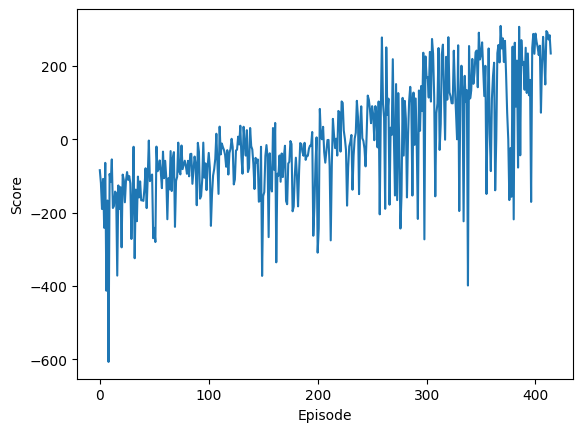

In [74]:
environment, number_of_observations, number_of_actions = create_environment()
agent = DQN(number_of_observations, number_of_actions)
episode = 0
start_time = time.perf_counter()
total_steps = 0
exploration_rate = EXPLORATION_RATE_MAX
goal_reached = False
while (episode < MAX_EPISODES_FOR_TRAINING) and not(goal_reached):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state
        action = agent.select_epsilon_greedy_policy(state, exploration_rate)

        # Execute the action on the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        total_steps += 1
        
        done = terminal_state or truncated

        # Store in memory the transition (s,a,r,s')
        agent.remember(state, action, reward, state_next, done)

        score += reward

        # Learn using a batch of experience stored in memory
        agent.learn()

        # Detect end of episode
        if terminal_state or truncated:
            end_episode = True
            agent.add_score(score)
            average_score = agent.average_score(EPISODES_TO_CHECK_TRAINING_GOAL)
            if average_score >= TRAINING_GOAL: goal_reached = True
            print("Episode {0:>3}: ".format(episode), end = '')
            print("score {0:>3} ".format(math.trunc(score)), end = '')
            print("(exploration rate: %.3f, " % exploration_rate, end = '')
            print("average score: {0:>3}, ".format(round(average_score)), end = '')
            print("transitions: " + str(agent.memory.current_size) + ")")
        else:
            state = state_next
            
    # Decrease exploration rate
    exploration_rate *= EXPLORATION_RATE_DECAY
    exploration_rate = max(EXPLORATION_RATE_MIN, exploration_rate)

print("Time for training: ", end = '')
print_time(time.perf_counter() - start_time)
print("Total steps: ", total_steps)
print("Score (average last episodes):", round(average_score))
print("Score (max):", round(max(agent.scores)))

agent.display_scores_graphically()

agent.save_model()


## Testing program



In [75]:
episode = 0
score_list = []
while (episode < EPISODES_TO_EVALUATE_MODEL_PERFORMANCE):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state
        action = agent.select_greedy_policy(state)

        # Execute the action in the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)
        
        score += reward
        state = state_next
        end_episode = terminal_state or truncated
        
    score_list.append(score)
    print("Episode {0:>3}: ".format(episode), end = '')
    print("score {0:>3} \n".format(round(score)), end = '')
                
print("Score (average):", round(np.mean(score_list)))

Episode   1: score 264 
Episode   2: score 276 
Episode   3: score 277 
Episode   4: score 274 
Episode   5: score 276 
Episode   6: score 285 
Episode   7: score 276 
Episode   8: score 221 
Episode   9: score 164 
Episode  10: score 253 
Episode  11: score 153 
Episode  12: score 110 
Episode  13: score 291 
Episode  14: score 213 
Episode  15: score 201 
Episode  16: score 253 
Episode  17: score 281 
Episode  18: score 291 
Episode  19: score  67 
Episode  20: score 103 
Episode  21: score 272 
Episode  22: score 292 
Episode  23: score 115 
Episode  24: score 252 
Episode  25: score 254 
Episode  26: score 277 
Episode  27: score 271 
Episode  28: score 242 
Episode  29: score 275 
Episode  30: score 243 
Score (average): 234


# Memoria

## Primera prueba

Se sustituyó el entorno original `CartPole-v1` por `LunarLander-v3`. Además, para realizar una primera prueba rápida, se modificaron algunos hiperparámetros:

```python
EPISODES_TO_CHECK_TRAINING_GOAL = 30
TRAINING_GOAL = 200
MAX_EPISODES_FOR_TRAINING = 50
```

No se modificó la arquitectura de la red ni el resto de la lógica principal del algoritmo.

### Resultados

- **Pasos totales de entrenamiento:** 5728
- **Puntuación media final en entrenamiento:** -102
- **Puntuación máxima en entrenamiento:** -9
- **Puntuación media en test (30 episodios):** -214

### Conclusión

El cambio de entorno por sí solo no es suficiente para obtener un comportamiento aceptable en `LunarLander-v3`. Aunque el código ejecuta correctamente, el rendimiento sigue siendo muy bajo, por lo que será necesario modificar la arquitectura o los hiperparámetros en los siguientes experimentos.

## Segunda prueba

Se introdujo una **target network** para estabilizar el aprendizaje del algoritmo DQN, de forma que los valores objetivo no se calcularan con la misma red que se actualiza en cada iteración. Además, se aumentó la capacidad de la red neuronal a dos capas ocultas de 128 neuronas con activación ReLU, y se incrementó el número máximo de episodios de entrenamiento a 300. También se corrigió el almacenamiento de transiciones finales usando `terminated or truncated`.

### Justificación

Este cambio se realizó porque en Deep Q-Learning se recomienda utilizar una red objetivo separada para reducir la inestabilidad del entrenamiento. Además, dado que `LunarLander-v3` es un entorno más complejo que `CartPole-v1`, se consideró razonable aumentar la complejidad del modelo y entrenar durante más episodios.

### Resultados

- **Pasos totales de entrenamiento:** 90503
- **Puntuación media final en entrenamiento:** -2
- **Puntuación máxima en entrenamiento:** 269
- **Puntuación media en test (30 episodios):** 45

### Conclusión

Este cambio produjo una mejora clara respecto a la primera prueba, ya que el agente empezó a obtener episodios con puntuaciones positivas e incluso alcanzó una puntuación máxima de 269 durante el entrenamiento. Sin embargo, la puntuación media en test sigue siendo insuficiente.

## Tercer prueba

Se mantuvo la configuración de la segunda prueba, incluyendo la **target network**, la red neuronal con dos capas ocultas de 128 neuronas y la corrección del almacenamiento de transiciones finales. En esta prueba únicamente se aumentó el número máximo de episodios de entrenamiento de 300 a 600.

### Justificación

Este cambio se realizó para comprobar si la política aprendida en la segunda prueba podía seguir mejorando simplemente aumentando el tiempo de entrenamiento. Una de las estrategias para mejorar el rendimiento de una red es aumentar el número de iteraciones cuando el ajuste todavía es insuficiente.

### Resultados

- **Pasos totales de entrenamiento:** 198426
- **Puntuación media final en entrenamiento:** 202
- **Puntuación máxima en entrenamiento:** 306
- **Puntuación media en test (30 episodios):** 187

### Conclusión

Este cambio mejoró claramente los resultados de la segunda prueba. La puntuación media en test pasó de 45 a 187, y durante el entrenamiento se alcanzó una media final de 202 y una puntuación máxima de 306. Por tanto, aumentar el número de episodios de entrenamiento fue una decisión acertada, aunque todavía no se alcanza el objetivo de 200 puntos de media en test.

## Cuarta prueba

Se mantuvo la configuración de la tercera prueba y únicamente se redujo la tasa de aprendizaje, cambiando:

```python
LEARNING_RATE = 0.0005
```

### Justificación

Este cambio se realizó para comprobar si una tasa de aprendizaje más baja permite estabilizar mejor el proceso de entrenamiento y consolidar la política aprendida. Dado que en la tercera prueba el agente ya consiguió una puntuación media de 187 en test, muy próxima al objetivo, esta modificación busca un ajuste fino que permita mejorar la generalización sin alterar el resto de la configuración.

### Resultados

- **Pasos totales de entrenamiento:** 164319
- **Puntuación media final en entrenamiento:** 201
- **Puntuación máxima en entrenamiento:** 288
- **Puntuación media en test (30 episodios):** 232

### Conclusion

Este cambio mejoró claramente los resultados de la tercera prueba. La puntuación media en test pasó de 187 a 232, superando el objetivo de 200 puntos de media exigido por la práctica. Además, durante el entrenamiento se alcanzó una media final de 201 y una puntuación máxima de 288. Por tanto, reducir la tasa de aprendizaje fue una decisión acertada.

## Quinta prueba

Se mantuvo la configuración de la cuarta prueba, incluyendo la red neuronal con dos capas ocultas de 128 neuronas, la tasa de aprendizaje reducida (`LEARNING_RATE = 0.0005`) y el entrenamiento con parada anticipada al alcanzar el objetivo. En esta prueba únicamente se modificó la frecuencia de actualización de la **target network**, cambiando:

```python
TARGET_UPDATE_FREQUENCY = 500
```

### Justificación

Este cambio se realizó para comprobar si una actualización menos frecuente de la target network permite estabilizar mejor el aprendizaje. En Deep Q-Learning, la red objetivo se utiliza para reducir la variabilidad del target durante el entrenamiento, por lo que espaciar sus actualizaciones podría ayudar a consolidar una política más estable sin modificar el resto de la configuración.


### Resultados

- **Pasos totales de entrenamiento:** 174802
- **Puntuación media final en entrenamiento:** 206
- **Puntuación máxima en entrenamiento:** 309
- **Puntuación media en test (30 episodios):** 234

### Conclusion

Este cambio mantuvo un rendimiento alto y permitió seguir superando el objetivo de 200 puntos de media en test. Sin embargo, la mejora respecto a la cuarta prueba fue mínima, ya que la puntuación media en test solo pasó de 232 a 234, a costa de un mayor número de pasos de entrenamiento. Por tanto, aunque la configuración sigue siendo válida, no aporta una mejora relevante frente a la cuarta prueba.

Estas pruebas permitieron identificar una versión final del agente DQN para `LunarLander-v3`, mostrando además, a través de las distintas pruebas intermedias, qué modificaciones resultaron realmente útiles y cuáles no aportaron mejoras significativas.

In [77]:
import tensorflow as tf

model = tf.keras.models.load_model("my_model.keras")
model.summary()

for layer in model.layers:
    print(layer.name)
    print(layer.get_weights())

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,542 (213.06 KB)

 Trainable params: 18,180 (71.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36,362 (142.04 KB)

dense_42
[array([[ 0.21249957, -0.5546107 ,  0.06290743, ...,  0.6431155 ,
        -0.54312295, -1.2967302 ],
       [ 0.13539118, -1.1575006 , -0.16923678, ...,  1.8479041 ,
        -0.92815846, -1.7396216 ],
       [ 0.05955703, -1.2756208 ,  0.7393098 , ..., -0.67289954,
        -0.49603367, -0.8318513 ],
       ...,
       [-0.52409   , -0.7282408 , -1.118114  , ...,  0.3794362 ,
         0.74870807,  0.08246832],
       [ 0.04643398, -1.5955274 ,  0.19224674, ...,  0.6895936 ,
         0.8843625 ,  0.43406633],
       [ 0.68532795, -1.1284239 , -0.17184676, ..., -0.4334445 ,
        -0.2046174 ,  0.16736907]], dtype=float32), array([ 2.6702297e-01,  3.7732652e-01,  1.2156863e+00, -1.1080414e-01,
        4.2805770e-01, -7.8151867e-02, -1.0792700e-01, -8.0471568e-02,
        4.9019143e-01,  2.7197788e-02,  1.6965631e-01, -8.6044766e-02,
        7.0981449e-01,  4.1349638e-01,  3.3768883e-01, -1.4352128e-01,
        3.5137512e-02,  6.6850621e-01, -4.7815898e-01,  6.8317711e-01,
      